In [1]:
# install required packages
!pip install transformers torch scikit-learn beautifulsoup4 requests pandas numpy tqdm -q

^C



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

# ── Core imports ───────────────────────────────────────────────────────

import requests

from bs4 import BeautifulSoup

import pandas as pd

import numpy as np

import time

import re

import warnings

warnings.filterwarnings('ignore')

# PyTorch

import torch

from torch.utils.data import Dataset, DataLoader

import torch.nn as nn

# Hugging Face Transformers

from transformers import (

    BertTokenizer,

    BertForSequenceClassification,

    get_linear_schedule_with_warmup

)

# Sklearn

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder
 
LabelEncoder

# Visualization

import matplotlib.pyplot as plt

import seaborn as sns

from tqdm import tqdm

print('imported successfully...')


imported successfully...


In [3]:
# ── Device setup ───────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Libraries loaded successfully")

print(f"🖥️  Using device: {device}")



✅ Libraries loaded successfully
🖥️  Using device: cpu


In [4]:
# ── Category → MedlinePlus URL mapping ────────────────────────────────

CATEGORIES = {

    "Heart Disease" : "https://medlineplus.gov/heartdiseases.html",

    "Diabetes"      : "https://medlineplus.gov/diabetes.html",

    "Mental Health" : "https://medlineplus.gov/mentalhealth.html",

    "Cancer"        : "https://medlineplus.gov/cancer.html",

    "Nutrition"     : "https://medlineplus.gov/nutrition.html",

}




In [5]:
HEADERS = {

    'User-Agent': 'Mozilla/5.0 (Educational Research Bot)'

}

In [6]:
def scrape_medlineplus(url, category, max_articles=40):
   """
   Scrapes health article headlines and summaries from a MedlinePlus topic page.
   Returns a list of dicts: {text, category}
   """
   articles = []
   try:
       response = requests.get(url, headers=HEADERS, timeout=15)
       response.raise_for_status()
       soup = BeautifulSoup(response.text, 'html.parser')
       # MedlinePlus news items appear in <ul> with class 'ul-links-news'
       # and also in article summary sections — we grab both
       seen = set()
       # ── Method 1: News link items ──────────────────────────────────
       news_items = soup.select('ul.ul-links-news li a, #section-news li a')
       for item in news_items:
           text = item.get_text(strip=True)
           if len(text) > 30 and text not in seen:
               articles.append({'text': text, 'category': category})
               seen.add(text)
       # ── Method 2: Summary paragraphs & headers ─────────────────────
       summary_items = soup.select(
           '#section-summary p, #section-summary li, '
           '.section-body p, .topic-summary p'
       )
       for item in summary_items:
           text = item.get_text(strip=True)
           text = re.sub(r'\s+', ' ', text)
           if len(text) > 50 and text not in seen:
               articles.append({'text': text[:300], 'category': category})
               seen.add(text)
       # ── Method 3: Any <li> or <a> inside known content divs ────────
       fallback = soup.select('div#topic-summary li, div.section li')
       for item in fallback:
           text = item.get_text(strip=True)
           if len(text) > 40 and text not in seen:
               articles.append({'text': text[:300], 'category': category})
               seen.add(text)
   except Exception as e:
       print(f"  ⚠️  Could not scrape {url}: {e}")
   return articles[:max_articles]

In [7]:
# ── Scrape all categories ──────────────────────────────────────────────
print("🌐 Scraping MedlinePlus health topics...\n")
all_articles = []

for category, url in CATEGORIES.items():
 articles = scrape_medlineplus(url, category, max_articles=40)
 all_articles.extend(articles)
 print(f"  ✅  {category:20s} → {len(articles):3d} articles scraped")
 time.sleep(1)   # polite delay between requests
print(f"\n📦 Total raw articles scraped: {len(all_articles)}")

print(all_articles[0])

🌐 Scraping MedlinePlus health topics...

  ✅  Heart Disease        →  40 articles scraped
  ✅  Diabetes             →  40 articles scraped
  ✅  Mental Health        →  32 articles scraped
  ✅  Cancer               →  40 articles scraped
  ✅  Nutrition            →  40 articles scraped

📦 Total raw articles scraped: 192
{'text': 'Angina- chest pain from lack of blood flow', 'category': 'Heart Disease'}


In [8]:
# ── Curated seed samples (domain-expert backup) ────────────────────────
# These ensure each class has representative samples regardless of
# what was successfully scraped on the day of the session
SEED_SAMPLES = [
   # Heart Disease
   {"text": "High blood pressure increases the risk of heart attack and stroke significantly.", "category": "Heart Disease"},
   {"text": "Cholesterol plaques in coronary arteries can lead to chest pain and cardiac events.", "category": "Heart Disease"},
   {"text": "Atrial fibrillation is an irregular heartbeat that raises risk of blood clots.", "category": "Heart Disease"},
   {"text": "Cardiologists recommend regular ECG screening for patients over 50 years old.", "category": "Heart Disease"},
   {"text": "Heart failure occurs when the heart muscle cannot pump enough blood to meet the body needs.", "category": "Heart Disease"},
   {"text": "Bypass surgery restores blood flow to blocked coronary arteries in severe cases.", "category": "Heart Disease"},
   {"text": "Statins are prescribed to lower LDL cholesterol and reduce cardiovascular disease risk.", "category": "Heart Disease"},
   {"text": "A myocardial infarction happens when blood supply to part of the heart is cut off.", "category": "Heart Disease"},
   {"text": "Lifestyle changes including diet exercise and quitting smoking benefit heart health.", "category": "Heart Disease"},
   {"text": "Echocardiograms use ultrasound waves to create images of heart structure and function.", "category": "Heart Disease"},
   # Diabetes
   {"text": "Type 2 diabetes develops when cells become resistant to insulin and blood sugar rises.", "category": "Diabetes"},
   {"text": "Continuous glucose monitors help diabetic patients track blood sugar in real time.", "category": "Diabetes"},
   {"text": "Metformin is the first-line medication prescribed for managing type 2 diabetes.", "category": "Diabetes"},
   {"text": "Uncontrolled diabetes can lead to kidney damage nerve damage and vision loss.", "category": "Diabetes"},
   {"text": "HbA1c test measures average blood glucose levels over the past two to three months.", "category": "Diabetes"},
   {"text": "Insulin therapy is essential for patients with type 1 diabetes to survive.", "category": "Diabetes"},
   {"text": "Gestational diabetes occurs during pregnancy and can affect both mother and baby.", "category": "Diabetes"},
   {"text": "Diabetic retinopathy is a leading cause of blindness in working-age adults worldwide.", "category": "Diabetes"},
   {"text": "Regular foot care is critical for diabetic patients to prevent ulcers and amputations.", "category": "Diabetes"},
   {"text": "Low carbohydrate diets have shown promise in improving insulin sensitivity in diabetics.", "category": "Diabetes"},
   # Mental Health
   {"text": "Depression affects millions worldwide and is characterized by persistent sadness and loss of interest.", "category": "Mental Health"},
   {"text": "Cognitive behavioral therapy has strong evidence for treating anxiety and depression disorders.", "category": "Mental Health"},
   {"text": "Antidepressants like SSRIs work by increasing serotonin availability in the brain.", "category": "Mental Health"},
   {"text": "Post-traumatic stress disorder can develop after experiencing or witnessing a traumatic event.", "category": "Mental Health"},
   {"text": "Mindfulness meditation practice can reduce symptoms of anxiety and improve emotional regulation.", "category": "Mental Health"},
   {"text": "Schizophrenia is a severe mental disorder that affects how a person thinks feels and behaves.", "category": "Mental Health"},
   {"text": "Bipolar disorder involves extreme mood swings from depression to mania and hypomania.", "category": "Mental Health"},
   {"text": "Early intervention for mental health disorders leads to significantly better long-term outcomes.", "category": "Mental Health"},
   {"text": "Social isolation and loneliness are strongly linked to increased risk of mental illness.", "category": "Mental Health"},
   {"text": "Teletherapy and digital mental health apps have expanded access to psychological support.", "category": "Mental Health"},
   # Cancer
   {"text": "Chemotherapy targets rapidly dividing cells but also affects healthy tissue causing side effects.", "category": "Cancer"},
   {"text": "Breast cancer screening with mammography can detect tumors before symptoms appear.", "category": "Cancer"},
   {"text": "Immunotherapy harnesses the immune system to recognize and destroy cancer cells.", "category": "Cancer"},
   {"text": "Lung cancer is the leading cause of cancer death worldwide and is strongly linked to smoking.", "category": "Cancer"},
   {"text": "Prostate specific antigen PSA testing is used to screen for prostate cancer in men.", "category": "Cancer"},
   {"text": "Genetic mutations in BRCA1 and BRCA2 genes significantly increase breast cancer risk.", "category": "Cancer"},
   {"text": "Radiation therapy uses high energy beams to kill cancer cells and shrink tumors.", "category": "Cancer"},
   {"text": "Colorectal cancer rates are rising among younger adults under 50 years old.", "category": "Cancer"},
   {"text": "Targeted therapy drugs block specific molecules involved in cancer cell growth and spread.", "category": "Cancer"},
   {"text": "Palliative care focuses on providing relief from symptoms and improving quality of life.", "category": "Cancer"},
   # Nutrition
   {"text": "A Mediterranean diet rich in olive oil fish and vegetables reduces chronic disease risk.", "category": "Nutrition"},
   {"text": "Excessive sugar consumption is linked to obesity type 2 diabetes and fatty liver disease.", "category": "Nutrition"},
   {"text": "Omega-3 fatty acids found in fish and flaxseed support brain and cardiovascular health.", "category": "Nutrition"},
   {"text": "Vitamin D deficiency is associated with bone loss immune dysfunction and depression.", "category": "Nutrition"},
   {"text": "Dietary fiber from whole grains legumes and vegetables promotes gut microbiome health.", "category": "Nutrition"},
   {"text": "Ultra-processed foods high in sodium and trans fats increase cardiovascular disease risk.", "category": "Nutrition"},
   {"text": "Iron deficiency anemia is the most common nutritional deficiency globally affecting billions.", "category": "Nutrition"},
   {"text": "Antioxidants in fruits and vegetables protect cells from oxidative stress and inflammation.", "category": "Nutrition"},
   {"text": "Intermittent fasting has shown potential benefits for weight loss and metabolic health.", "category": "Nutrition"},
   {"text": "Adequate protein intake is essential for muscle repair immune function and hormone production.", "category": "Nutrition"},
]
print(f"📌 Curated seed samples ready: {len(SEED_SAMPLES)}")

📌 Curated seed samples ready: 50


In [9]:
df_scraped = pd.DataFrame(all_articles)
df_seed    = pd.DataFrame(SEED_SAMPLES)
df         = pd.concat([df_scraped, df_seed], ignore_index=True)

In [10]:
# ── Basic cleaning ─────────────────────────────────────────────────────
df['text'] = df['text'].str.strip()
df = df[df['text'].str.len() > 30]   # remove very short entries
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print("📊 Dataset Summary")
print("=" * 40)
print(f"Total samples : {len(df)}")
print(f"Scraped        : {len(df_scraped)}")
print(f"Seed samples   : {len(df_seed)}")
print()
print("Samples per category:")
print(df['category'].value_counts())

📊 Dataset Summary
Total samples : 241
Scraped        : 192
Seed samples   : 50

Samples per category:
category
Heart Disease    50
Diabetes         50
Cancer           50
Nutrition        49
Mental Health    42
Name: count, dtype: int64


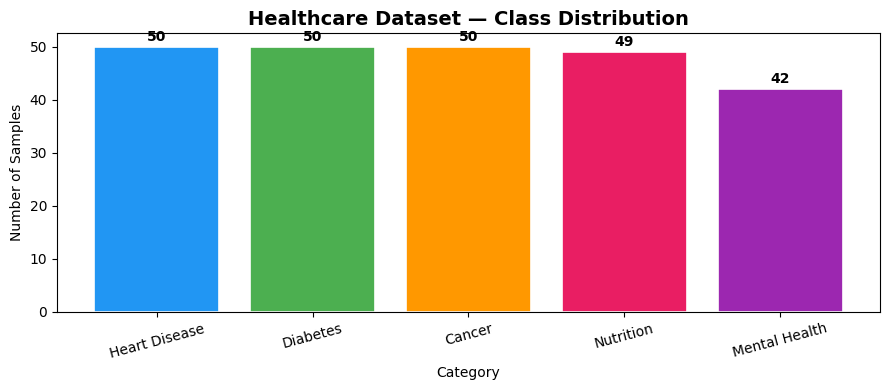

In [11]:
plt.figure(figsize=(9, 4))
counts = df['category'].value_counts()
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
   plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontweight='bold')
plt.title('Healthcare Dataset — Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()